# 配对图像与数据划分

这张 BCI 作者预览拼图展示了两种染色的外观。它含文字与拼版裁切，只用于辨认染色；配对位置和数值误差另用明确标注的教学算例说明。

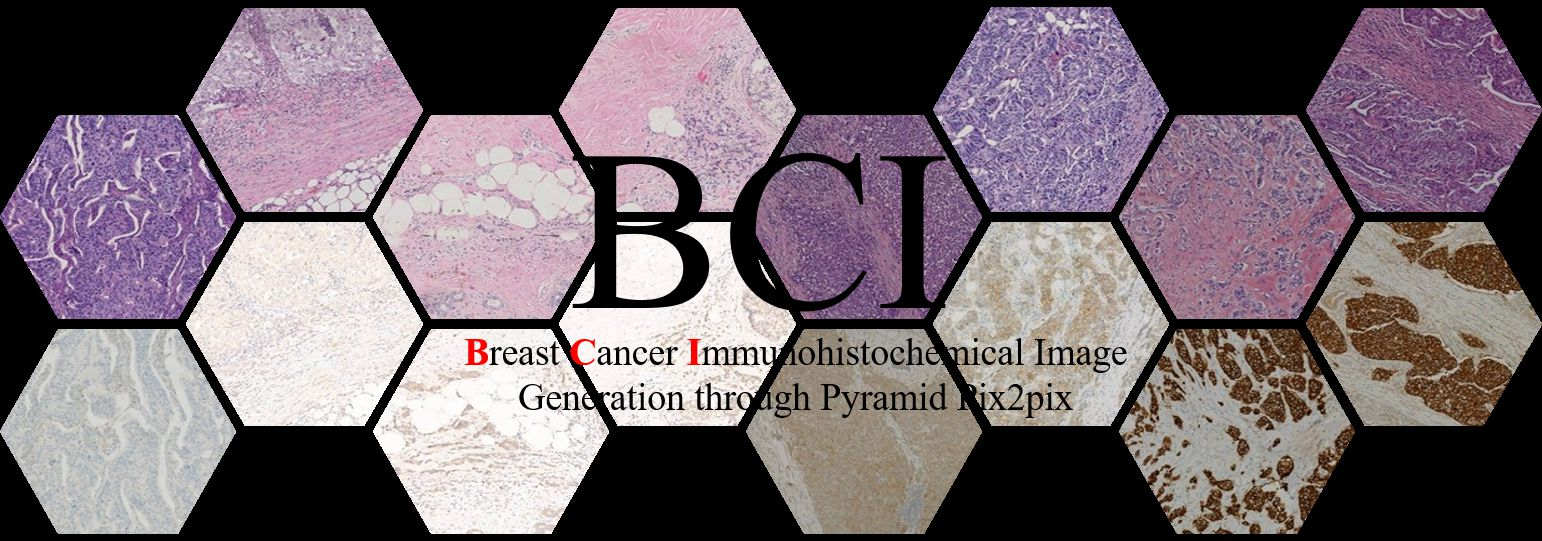

预览保留原尺寸，转为 JPEG 用于显示。预览来源：BCI 作者公开仓库；依作者许可用于非商业教学与科研。

在 Kaggle 中建立自己的副本后，从第一格开始运行。每个知识点有独立的代码格，修改其中的示例数值或设置，再重新运行该格；若它改变了后面要用的变量，也运行后续代码。最后用 **Save Version → Save & Run All** 保存输出。图片已随本文件提供，无需打开网站或联网下载。

运行下面一格后，照片会直接显示。样本编码已折叠，后面的代码按知识点分别运行；每处的注释指出可以改动的数值。

In [1]:
from pathlib import Path
from copy import deepcopy
import base64, json, csv, io
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display

torch.manual_seed(7)  # 让教学算例使用相同随机起点
torch.set_num_threads(2)  # 小练习只使用少量 CPU 线程
if any(f.name == 'Microsoft YaHei' for f in font_manager.fontManager.ttflist):
    plt.rcParams['font.family'] = 'Microsoft YaHei'
plt.rcParams['axes.unicode_minus'] = False
WORK = Path('/kaggle/working') if Path('/kaggle/working').is_absolute() and Path('/kaggle/working').exists() else Path('knowledge_outputs')
WORK.mkdir(parents=True, exist_ok=True)
ASSETS = WORK / 'lesson_assets'
ASSETS.mkdir(exist_ok=True)

BUNDLED = {'fonts/KYDWLearningSans.otf': '...', 'fonts/OFL.txt': 'wqkgMjAxNC0yMDIxIEFkb2JlIChodHRwOi8vd3d3LmFkb2JlLmNvbS8pLgoKVGhpcyBGb250IFNvZnR3YXJlIGlzIGxpY2Vuc2VkIHVuZGVyIHRoZSBTSUwgT3BlbiBGb250IExpY2Vuc2UsClZlcnNpb24gMS4xLgoKVGhpcyBsaWNlbnNlIGlzIGNvcGllZCBiZWxvdywgYW5kIGlzIGFsc28gYXZhaWxhYmxlIHdpdGggYSBGQVEgYXQ6Cmh0dHA6Ly9zY3JpcHRzLnNpbC5vcmcvT0ZMCgotLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLQpTSUwgT1BFTiBGT05UIExJQ0VOU0UgVmVyc2lvbiAxLjEgLSAyNiBGZWJydWFyeSAyMDA3Ci0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tCgpQUkVBTUJMRQpUaGUgZ29hbHMgb2YgdGhlIE9wZW4gRm9udCBMaWNlbnNlIChPRkwpIGFyZSB0byBzdGltdWxhdGUgd29ybGR3aWRlCmRldmVsb3BtZW50IG9mIGNvbGxhYm9yYXRpdmUgZm9udCBwcm9qZWN0cywgdG8gc3VwcG9ydCB0aGUgZm9udApjcmVhdGlvbiBlZmZvcnRzIG9mIGFjYWRlbWljIGFuZCBsaW5ndWlzdGljIGNvbW11bml0aWVzLCBhbmQgdG8KcHJvdmlkZSBhIGZyZWUgYW5kIG9wZW4gZnJhbWV3b3JrIGluIHdoaWNoIGZvbnRzIG1heSBiZSBzaGFyZWQgYW5kCmltcHJvdmVkIGluIHBhcnRuZXJzaGlwIHdpdGggb3RoZXJzLgoKVGhlIE9GTCBhbGxvd3MgdGhlIGxpY2Vuc2VkIGZvbnRzIHRvIGJlIHVzZWQsIHN0dWRpZWQsIG1vZGlmaWVkIGFuZApyZWRpc3RyaWJ1dGVkIGZyZWVseSBhcyBsb25nIGFzIHRoZXkgYXJlIG5vdCBzb2xkIGJ5IHRoZW1zZWx2ZXMuIFRoZQpmb250cywgaW5jbHVkaW5nIGFueSBkZXJpdmF0aXZlIHdvcmtzLCBjYW4gYmUgYnVuZGxlZCwgZW1iZWRkZWQsCnJlZGlzdHJpYnV0ZWQgYW5kL29yIHNvbGQgd2l0aCBhbnkgc29mdHdhcmUgcHJvdmlkZWQgdGhhdCBhbnkgcmVzZXJ2ZWQKbmFtZXMgYXJlIG5vdCB1c2VkIGJ5IGRlcml2YXRpdmUgd29ya3MuIFRoZSBmb250cyBhbmQgZGVyaXZhdGl2ZXMsCmhvd2V2ZXIsIGNhbm5vdCBiZSByZWxlYXNlZCB1bmRlciBhbnkgb3RoZXIgdHlwZSBvZiBsaWNlbnNlLiBUaGUKcmVxdWlyZW1lbnQgZm9yIGZvbnRzIHRvIHJlbWFpbiB1bmRlciB0aGlzIGxpY2Vuc2UgZG9lcyBub3QgYXBwbHkgdG8KYW55IGRvY3VtZW50IGNyZWF0ZWQgdXNpbmcgdGhlIGZvbnRzIG9yIHRoZWlyIGRlcml2YXRpdmVzLgoKREVGSU5JVElPTlMKIkZvbnQgU29mdHdhcmUiIHJlZmVycyB0byB0aGUgc2V0IG9mIGZpbGVzIHJlbGVhc2VkIGJ5IHRoZSBDb3B5cmlnaHQKSG9sZGVyKHMpIHVuZGVyIHRoaXMgbGljZW5zZSBhbmQgY2xlYXJseSBtYXJrZWQgYXMgc3VjaC4gVGhpcyBtYXkKaW5jbHVkZSBzb3VyY2UgZmlsZXMsIGJ1aWxkIHNjcmlwdHMgYW5kIGRvY3VtZW50YXRpb24uCgoiUmVzZXJ2ZWQgRm9udCBOYW1lIiByZWZlcnMgdG8gYW55IG5hbWVzIHNwZWNpZmllZCBhcyBzdWNoIGFmdGVyIHRoZQpjb3B5cmlnaHQgc3RhdGVtZW50KHMpLgoKIk9yaWdpbmFsIFZlcnNpb24iIHJlZmVycyB0byB0aGUgY29sbGVjdGlvbiBvZiBGb250IFNvZnR3YXJlCmNvbXBvbmVudHMgYXMgZGlzdHJpYnV0ZWQgYnkgdGhlIENvcHlyaWdodCBIb2xkZXIocykuCgoiTW9kaWZpZWQgVmVyc2lvbiIgcmVmZXJzIHRvIGFueSBkZXJpdmF0aXZlIG1hZGUgYnkgYWRkaW5nIHRvLApkZWxldGluZywgb3Igc3Vic3RpdHV0aW5nIC0tIGluIHBhcnQgb3IgaW4gd2hvbGUgLS0gYW55IG9mIHRoZQpjb21wb25lbnRzIG9mIHRoZSBPcmlnaW5hbCBWZXJzaW9uLCBieSBjaGFuZ2luZyBmb3JtYXRzIG9yIGJ5IHBvcnRpbmcKdGhlIEZvbnQgU29mdHdhcmUgdG8gYSBuZXcgZW52aXJvbm1lbnQuCgoiQXV0aG9yIiByZWZlcnMgdG8gYW55IGRlc2lnbmVyLCBlbmdpbmVlciwgcHJvZ3JhbW1lciwgdGVjaG5pY2FsCndyaXRlciBvciBvdGhlciBwZXJzb24gd2hvIGNvbnRyaWJ1dGVkIHRvIHRoZSBGb250IFNvZnR3YXJlLgoKUEVSTUlTU0lPTiAmIENPTkRJVElPTlMKUGVybWlzc2lvbiBpcyBoZXJlYnkgZ3JhbnRlZCwgZnJlZSBvZiBjaGFyZ2UsIHRvIGFueSBwZXJzb24gb2J0YWluaW5nCmEgY29weSBvZiB0aGUgRm9udCBTb2Z0d2FyZSwgdG8gdXNlLCBzdHVkeSwgY29weSwgbWVyZ2UsIGVtYmVkLAptb2RpZnksIHJlZGlzdHJpYnV0ZSwgYW5kIHNlbGwgbW9kaWZpZWQgYW5kIHVubW9kaWZpZWQgY29waWVzIG9mIHRoZQpGb250IFNvZnR3YXJlLCBzdWJqZWN0IHRvIHRoZSBmb2xsb3dpbmcgY29uZGl0aW9uczoKCjEpIE5laXRoZXIgdGhlIEZvbnQgU29mdHdhcmUgbm9yIGFueSBvZiBpdHMgaW5kaXZpZHVhbCBjb21wb25lbnRzLCBpbgpPcmlnaW5hbCBvciBNb2RpZmllZCBWZXJzaW9ucywgbWF5IGJlIHNvbGQgYnkgaXRzZWxmLgoKMikgT3JpZ2luYWwgb3IgTW9kaWZpZWQgVmVyc2lvbnMgb2YgdGhlIEZvbnQgU29mdHdhcmUgbWF5IGJlIGJ1bmRsZWQsCnJlZGlzdHJpYnV0ZWQgYW5kL29yIHNvbGQgd2l0aCBhbnkgc29mdHdhcmUsIHByb3ZpZGVkIHRoYXQgZWFjaCBjb3B5CmNvbnRhaW5zIHRoZSBhYm92ZSBjb3B5cmlnaHQgbm90aWNlIGFuZCB0aGlzIGxpY2Vuc2UuIFRoZXNlIGNhbiBiZQppbmNsdWRlZCBlaXRoZXIgYXMgc3RhbmQtYWxvbmUgdGV4dCBmaWxlcywgaHVtYW4tcmVhZGFibGUgaGVhZGVycyBvcgppbiB0aGUgYXBwcm9wcmlhdGUgbWFjaGluZS1yZWFkYWJsZSBtZXRhZGF0YSBmaWVsZHMgd2l0aGluIHRleHQgb3IKYmluYXJ5IGZpbGVzIGFzIGxvbmcgYXMgdGhvc2UgZmllbGRzIGNhbiBiZSBlYXNpbHkgdmlld2VkIGJ5IHRoZSB1c2VyLgoKMykgTm8gTW9kaWZpZWQgVmVyc2lvbiBvZiB0aGUgRm9udCBTb2Z0d2FyZSBtYXkgdXNlIHRoZSBSZXNlcnZlZCBGb250Ck5hbWUocykgdW5sZXNzIGV4cGxpY2l0IHdyaXR0ZW4gcGVybWlzc2lvbiBpcyBncmFudGVkIGJ5IHRoZQpjb3JyZXNwb25kaW5nIENvcHlyaWdodCBIb2xkZXIuIFRoaXMgcmVzdHJpY3Rpb24gb25seSBhcHBsaWVzIHRvIHRoZQpwcmltYXJ5IGZvbnQgbmFtZSBhcyBwcmVzZW50ZWQgdG8gdGhlIHVzZXJzLgoKNCkgVGhlIG5hbWUocykgb2YgdGhlIENvcHlyaWdodCBIb2xkZXIocykgb3IgdGhlIEF1dGhvcihzKSBvZiB0aGUgRm9udApTb2Z0d2FyZSBzaGFsbCBub3QgYmUgdXNlZCB0byBwcm9tb3RlLCBlbmRvcnNlIG9yIGFkdmVydGlzZSBhbnkKTW9kaWZpZWQgVmVyc2lvbiwgZXhjZXB0IHRvIGFja25vd2xlZGdlIHRoZSBjb250cmlidXRpb24ocykgb2YgdGhlCkNvcHlyaWdodCBIb2xkZXIocykgYW5kIHRoZSBBdXRob3Iocykgb3Igd2l0aCB0aGVpciBleHBsaWNpdCB3cml0dGVuCnBlcm1pc3Npb24uCgo1KSBUaGUgRm9udCBTb2Z0d2FyZSwgbW9kaWZpZWQgb3IgdW5tb2RpZmllZCwgaW4gcGFydCBvciBpbiB3aG9sZSwKbXVzdCBiZSBkaXN0cmlidXRlZCBlbnRpcmVseSB1bmRlciB0aGlzIGxpY2Vuc2UsIGFuZCBtdXN0IG5vdCBiZQpkaXN0cmlidXRlZCB1bmRlciBhbnkgb3RoZXIgbGljZW5zZS4gVGhlIHJlcXVpcmVtZW50IGZvciBmb250cyB0bwpyZW1haW4gdW5kZXIgdGhpcyBsaWNlbnNlIGRvZXMgbm90IGFwcGx5IHRvIGFueSBkb2N1bWVudCBjcmVhdGVkIHVzaW5nCnRoZSBGb250IFNvZnR3YXJlLgoKVEVSTUlOQVRJT04KVGhpcyBsaWNlbnNlIGJlY29tZXMgbnVsbCBhbmQgdm9pZCBpZiBhbnkgb2YgdGhlIGFib3ZlIGNvbmRpdGlvbnMgYXJlCm5vdCBtZXQuCgpESVNDTEFJTUVSClRIRSBGT05UIFNPRlRXQVJFIElTIFBST1ZJREVEICJBUyBJUyIsIFdJVEhPVVQgV0FSUkFOVFkgT0YgQU5ZIEtJTkQsCkVYUFJFU1MgT1IgSU1QTElFRCwgSU5DTFVESU5HIEJVVCBOT1QgTElNSVRFRCBUTyBBTlkgV0FSUkFOVElFUyBPRgpNRVJDSEFOVEFCSUxJVFksIEZJVE5FU1MgRk9SIEEgUEFSVElDVUxBUiBQVVJQT1NFIEFORCBOT05JTkZSSU5HRU1FTlQKT0YgQ09QWVJJR0hULCBQQVRFTlQsIFRSQURFTUFSSywgT1IgT1RIRVIgUklHSFQuIElOIE5PIEVWRU5UIFNIQUxMIFRIRQpDT1BZUklHSFQgSE9MREVSIEJFIExJQUJMRSBGT1IgQU5ZIENMQUlNLCBEQU1BR0VTIE9SIE9USEVSIExJQUJJTElUWSwKSU5DTFVESU5HIEFOWSBHRU5FUkFMLCBTUEVDSUFMLCBJTkRJUkVDVCwgSU5DSURFTlRBTCwgT1IgQ09OU0VRVUVOVElBTApEQU1BR0VTLCBXSEVUSEVSIElOIEFOIEFDVElPTiBPRiBDT05UUkFDVCwgVE9SVCBPUiBPVEhFUldJU0UsIEFSSVNJTkcKRlJPTSwgT1VUIE9GIFRIRSBVU0UgT1IgSU5BQklMSVRZIFRPIFVTRSBUSEUgRk9OVCBTT0ZUV0FSRSBPUiBGUk9NCk9USEVSIERFQUxJTkdTIElOIFRIRSBGT05UIFNPRlRXQVJFLgo=', 'bci-official-preview.jpg': '...'}

def fetch(name):
    path = ASSETS / name
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_bytes(base64.b64decode(BUNDLED[name]))  # 从本文件还原样本，不访问网站
    return path

class ImageReadMode:
    RGB = 'RGB'
    UNCHANGED = 'UNCHANGED'

def read_image(path, mode=ImageReadMode.UNCHANGED):
    im = Image.open(path)
    if mode == ImageReadMode.RGB:
        im = im.convert('RGB')
    a = np.array(im, copy=True)
    if a.ndim == 2:
        a = a[:, :, None]
    return torch.from_numpy(a).permute(2,0,1)  # 行列通道改为通道行列

def photo(name, size=64):
    im = Image.open(fetch(name)).convert('RGB').resize((size,size), Image.Resampling.BILINEAR)
    return torch.from_numpy(np.array(im,copy=True)).permute(2,0,1).float()/255

def view(items, titles, figsize=None):
    fig, axes = plt.subplots(1,len(items),figsize=figsize or (3*len(items),3),squeeze=False)
    for ax, im, title in zip(axes[0],items,titles):
        if isinstance(im,torch.Tensor):
            im=im.detach().cpu().numpy()
            if im.ndim==3 and im.shape[0] in (1,3,4): im=im.transpose(1,2,0)
        ax.imshow(im,cmap='gray' if np.asarray(im).ndim==2 else None)
        ax.set_title(title);ax.axis('off')
    plt.tight_layout();plt.show()

font_file = fetch('fonts/KYDWLearningSans.otf')  # 随练习提供中文绘图字形，无需联网安装
fetch('fonts/OFL.txt')  # 同时保存原字体版权与许可
font_manager.fontManager.addfont(str(font_file))
plt.rcParams['font.family'] = font_manager.FontProperties(fname=str(font_file)).get_name()
print('已载入 BCI 教学预览和绘图字体。')


已载入 BCI 教学预览和绘图字体。


## 病理图像外观

预览拼图中的紫粉色和棕色分别来自不同染色。它帮助我们辨认外观，拼版裁切部分不适合逐像素训练或评价。

来源：BCI 官方仓库；非商业教学与科研使用条款。

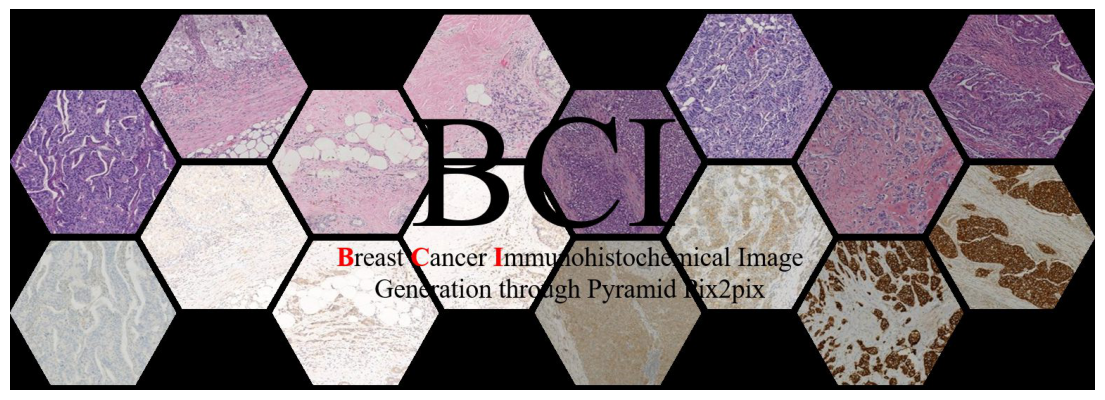

public preview: torch.Size([3, 541, 1542])


In [2]:
preview = read_image(str(fetch('bci-official-preview.jpg')),mode=ImageReadMode.RGB)
plt.figure(figsize=(14,5))
plt.imshow(preview.permute(1,2,0))
plt.axis('off')
plt.show()
print('public preview:',preview.shape)

## 配对几何操作

人工数值图的颜色具有明确的坐标规律，可用于核对位置对应。这样每个点的颜色规则都能算出来，输入与目标一起翻转后也能核对。

In [3]:
axis = torch.linspace(0, 1, 32)
yy, xx = torch.meshgrid(axis, axis, indexing='ij')
source = torch.stack([xx, yy, (xx + yy) / 2])[None]  # [1,3,32,32]，演示用坐标图
reference = torch.stack([1-xx, yy.square(), xx * yy])[None]  # 已知规则生成的数值目标
# 这两个张量用于观察运算，不是病理图像或模型研究结果

In [4]:
source_flip = source.flip(-1)
reference_flip = reference.flip(-1)
assert torch.allclose(reference_flip[:,0],1-source_flip[:,0])
wrong_target = reference.flip(-2)  # 故意使用不同方向，破坏空间对应
print('correct coordinate check:',torch.allclose(reference_flip[:,0],1-source_flip[:,0]))
print('wrong coordinate check:',torch.allclose(wrong_target[:,0],1-source_flip[:,0]))

correct coordinate check: True
wrong coordinate check: False


## 显示变换关系

对照第一行的原始位置和第二行的翻转结果。同步翻转保留同一组织位置的关系；只翻转一侧会改变对应关系。这里使用人工坐标图。

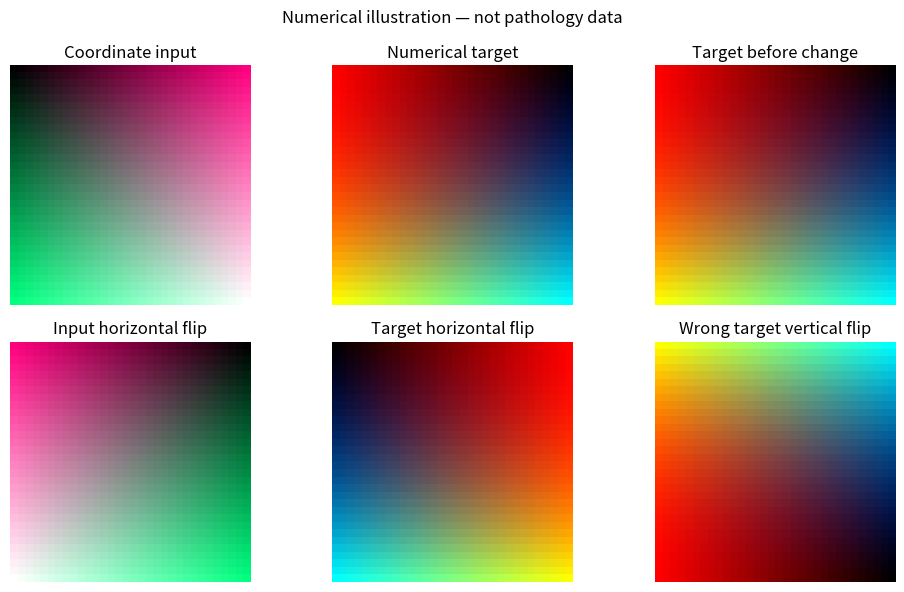

In [5]:
fig, axes = plt.subplots(2,3,figsize=(10,6))
panels = [source, reference, reference, source_flip, reference_flip, wrong_target]
titles = ['Coordinate input', 'Numerical target', 'Target before change',
          'Input horizontal flip', 'Target horizontal flip', 'Wrong target vertical flip']
for ax, values, title in zip(axes.flat, panels, titles):
    ax.imshow(values[0].permute(1,2,0))
    ax.set_title(title)
    ax.axis('off')
fig.suptitle('Numerical illustration — not pathology data')
fig.tight_layout()
plt.show()

## 分组与文件清单

同一切片可以产生很多图块。下面人工清单中，同组图块应一起分配；把某个组放入测试后，检查它是否仍留在训练。

In [6]:
records = [
    {'pair_id':'demo01','group':'slide_A','split':'train'},
    {'pair_id':'demo02','group':'slide_A','split':'train'},
    {'pair_id':'demo03','group':'slide_B','split':'validation'},
    {'pair_id':'demo04','group':'slide_C','split':'test'},
]
groups = {name:{r['group'] for r in records if r['split']==name} for name in ['train','validation','test']}
assert not groups['train'] & groups['validation']
assert not groups['train'] & groups['test']
assert not groups['validation'] & groups['test']
print(groups)

{'train': {'slide_A'}, 'validation': {'slide_B'}, 'test': {'slide_C'}}


## 小练习
下格单独复制清单，把 `TEST_GROUP` 改为 slide_A，观察训练与测试共享了哪一组；然后恢复为 slide_C。独立项目中另行核对每对文件存在、尺寸相同、颜色方向正确，并人工检查组织对应。将论文、下载版本、许可和划分依据写入数据卡。

In [7]:
TEST_GROUP = 'slide_C'  # 可改为 slide_A，观察同组样本跨集合的情况
trial_records = [dict(row) for row in records]  # 练习使用副本，原始清单保持可供比较
trial_records[-1]['group'] = TEST_GROUP
training_groups = {row['group'] for row in trial_records if row['split'] == 'train'}
test_groups = {row['group'] for row in trial_records if row['split'] == 'test'}
print('groups shared by training and test:', training_groups & test_groups)

groups shared by training and test: set()


## 局部查看与来源层级

预览拼图中的两个局部帮助辨认染色外观，不能据此推断它们的像素完全配准。下面用坐标裁出预览的一部分，记录裁剪框；真正训练时用原始配对文件和已有来源标识。

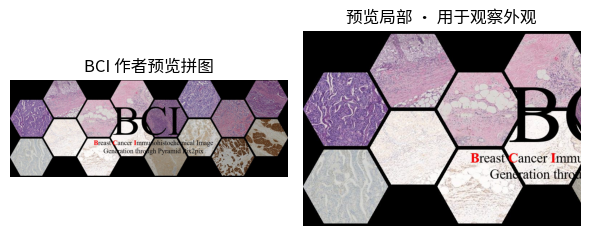

拼图尺寸: (1542, 541) 裁剪框: (0, 0, 771, 541)
记录来源时分别保留患者、切片、图块标识；没有提供的标识不能凭编号猜测。


In [8]:
preview_pil=Image.open(fetch('bci-official-preview.jpg')).convert('RGB')
W,H=preview_pil.size
BOX=(0,0,W//2,H)  # 可调整裁剪框；这是拼图局部，不是原始配对样本
view([preview_pil,preview_pil.crop(BOX)],['BCI 作者预览拼图','预览局部 · 用于观察外观'])
print('拼图尺寸:',preview_pil.size,'裁剪框:',BOX)
print('记录来源时分别保留患者、切片、图块标识；没有提供的标识不能凭编号猜测。')